# FSPS + PocoMC for one COSMOS2020 galaxy

This notebook fits the same representative galaxy with the FSPS continuity-SFH model.
PocoMC receives the Uniform and Student-t priors directly from `ParameterSpace`; the
likelihood remains backend-agnostic and mass is surviving stellar mass.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys
import numpy as np

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "composed").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
DATA_PATH = REPO_ROOT / "notebooks/tutorials/data/cosmos2020_ugrizYJH_100k.npz"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 00_prepare_cosmos2020_ugrizYJH.ipynb first.")

with np.load(DATA_PATH, allow_pickle=False) as catalog:
    flux = catalog["flux_maggies"]
    sigma = catalog["sigma_maggies"]
    z_reference = catalog["lp_zbest"]
    mass_reference = catalog["lp_mass_med"]
    sfr_reference = catalog["lp_sfr_med"]
    dust_reference = catalog["lp_dust"]
    BAND_NAMES = tuple(catalog["band_names"].astype(str))
    FILTER_NAMES = tuple(catalog["sedpy_filter_names"].astype(str))
    SINGLE_OBJECT = int(catalog["single_object_position"])

print(f"Loaded {flux.shape[0]:,} galaxies in {flux.shape[1]} bands")
print("Single tutorial object:", SINGLE_OBJECT, "z_ref=", z_reference[SINGLE_OBJECT])

from sedpy.observate import load_filters
from composed.filters import FilterSet

filters = FilterSet(load_filters(list(FILTER_NAMES)), names=BAND_NAMES)


Loaded 100,000 galaxies in 8 bands
Single tutorial object: 36096 z_ref= 1.0001


In [2]:
from composed import (
    ContinuitySFH, EmpiricalPhotometricNoise, Gaussian, ParameterSpace,
    Problem, SEDDataset, StudentTPrior, UniformPrior,
)
from composed.backends.fsps import FSPSBackend

sfh = ContinuitySFH(
    age="age_fraction",
    age_kind="fraction_of_universe",
    lookback_edges_gyr=(0.0, 0.01, 0.03, 0.1, 0.3),
    samples_per_bin=8,
)

parameters = ParameterSpace(
    names=("zred", "log10_mass", "logzsol", "dust2", "age_fraction", *sfh.ratio_names),
    priors={
        "zred": UniformPrior(0.05, 5.0),
        "log10_mass": UniformPrior(6.0, 13.0),
        "logzsol": UniformPrior(-1.5, 0.3),
        "dust2": UniformPrior(0.0, 2.0),
        "age_fraction": UniformPrior(0.30, 0.95),
        **{name: StudentTPrior(df=2.0, loc=0.0, scale=0.3) for name in sfh.ratio_names},
    },
)

backend = FSPSBackend(
    sfh=sfh,
    sp_kwargs={
        "sfh": 3, "imf_type": 1, "zcontinuous": 1, "dust_type": 2,
        "add_neb_emission": True, "add_igm_absorption": True,
        "add_dust_emission": False,
    },
    default_z_key="zred",
)
FRACTIONAL_MODEL_ERROR = 0.05
sigma_effective = np.sqrt(sigma**2 + (FRACTIONAL_MODEL_ERROR * np.abs(flux))**2)
noise_model = EmpiricalPhotometricNoise(
    sigma, fractional_error=FRACTIONAL_MODEL_ERROR, band_names=BAND_NAMES, flux_unit="maggies"
)
data = SEDDataset(BAND_NAMES, flux[SINGLE_OBJECT], sigma_effective[SINGLE_OBJECT], flux_unit="maggies")
problem = Problem(backend, parameters, data, Gaussian(), filters=filters)


## Fit


In [3]:
from composed import (
    PocoMC, fit, load_inference_result, posterior_summary,
    require_result_matches_problem, save_inference_result,
)

OUTPUT = REPO_ROOT / "outputs/tutorial_fsps_pocomc_single"
FORCE = os.environ.get("COMPOSED_TUTORIAL_FORCE", "0") == "1"
result = None
if (OUTPUT / "inference_result.npz").exists() and not FORCE:
    cached_result = load_inference_result(OUTPUT)
    try:
        result = require_result_matches_problem(cached_result, problem)
        print("Loaded saved PocoMC fit for this Problem")
    except ValueError as error:
        print(f"Ignoring stale PocoMC fit: {error}")

if result is None:
    result = fit(
        problem,
        PocoMC(
            sampler_kwargs={"n_effective": 512, "n_active": 256, "flow": "nsf6"},
            run_kwargs={"n_total": 4096, "n_evidence": 4096, "progress": True},
        ),
        seed=71,
    )
    save_inference_result(result, OUTPUT)
posterior_summary(result)


Loaded saved PocoMC fit


{'zred': {'q_lo': 0.916618915888364,
  'median': 0.9931238689384826,
  'q_hi': 1.0363791336666135,
  'map': 1.0130493399934333},
 'log10_mass': {'q_lo': 10.052861465699587,
  'median': 10.140807311147126,
  'q_hi': 10.232095073594577,
  'map': 10.251480992493988},
 'logzsol': {'q_lo': -1.148385657879273,
  'median': -0.7564836712923453,
  'q_hi': -0.30855485398584137,
  'map': -1.0553357368167315},
 'dust2': {'q_lo': 0.8636969597441918,
  'median': 1.0553378856746791,
  'q_hi': 1.240849731982766,
  'map': 1.0679502876847897},
 'age_fraction': {'q_lo': 0.4641248442718098,
  'median': 0.6398932285681704,
  'q_hi': 0.8289954521250158,
  'map': 0.8180766153698902},
 'logsfr_ratio_0': {'q_lo': -0.3250772000368233,
  'median': -0.0628914536374172,
  'q_hi': 0.18099841293388702,
  'map': -0.11846225342174145},
 'logsfr_ratio_1': {'q_lo': -0.339753359587256,
  'median': -0.07162424273912575,
  'q_hi': 0.17634119228152312,
  'map': -0.057119637229978995},
 'logsfr_ratio_2': {'q_lo': -0.34802931

## Posterior and posterior predictive SED


(<Figure size 800x330 with 1 Axes>,
 array([<Axes: xlabel='wavelength', ylabel='flux [photometry units]'>],
       dtype=object))

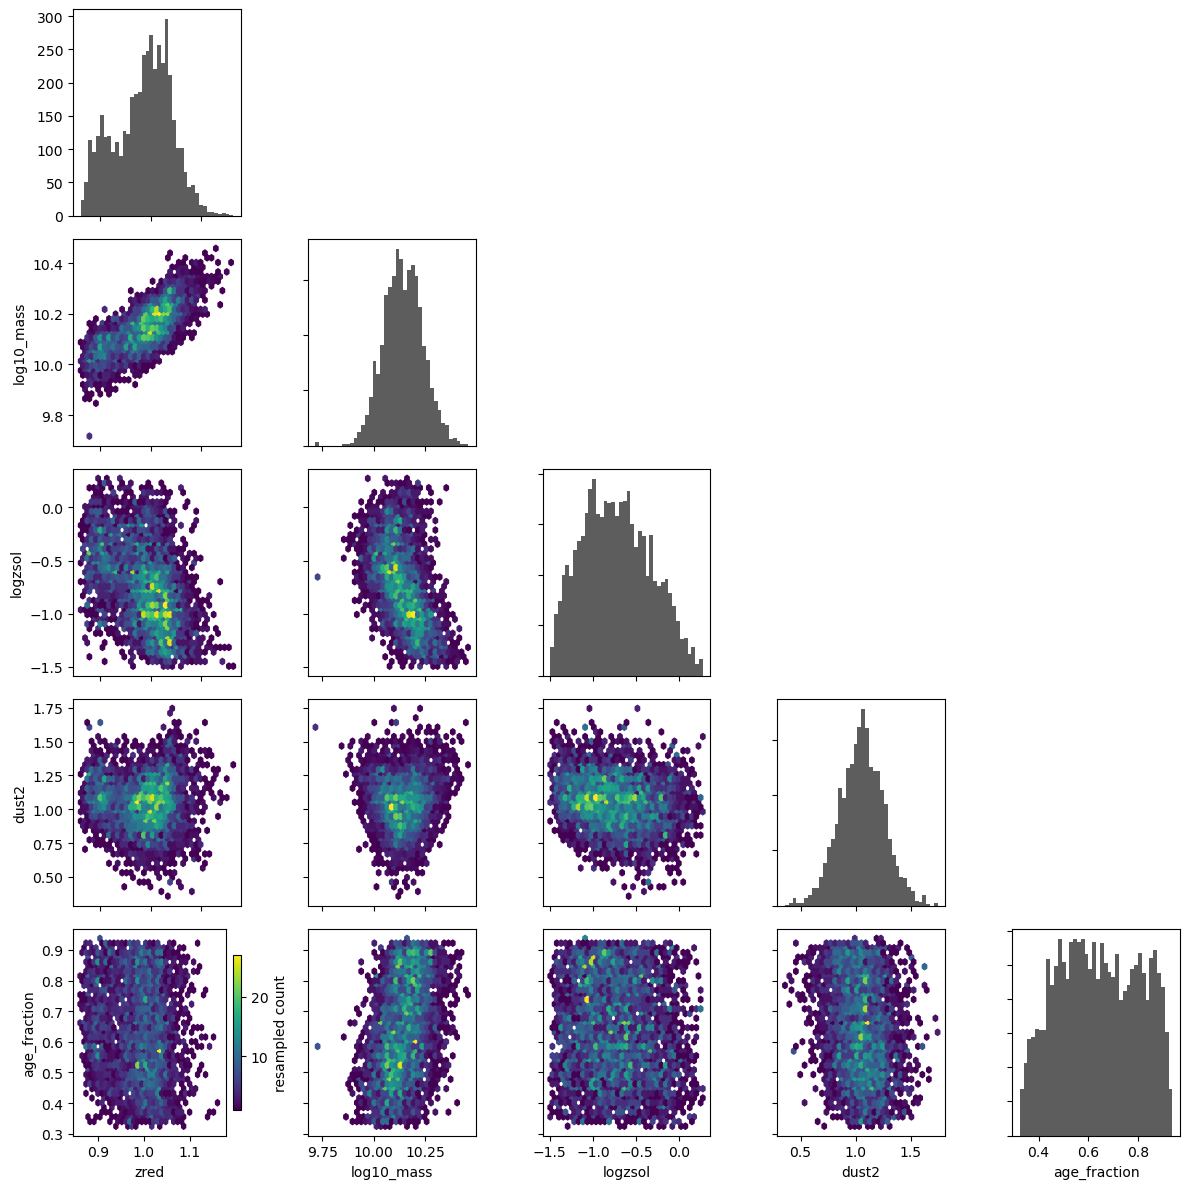

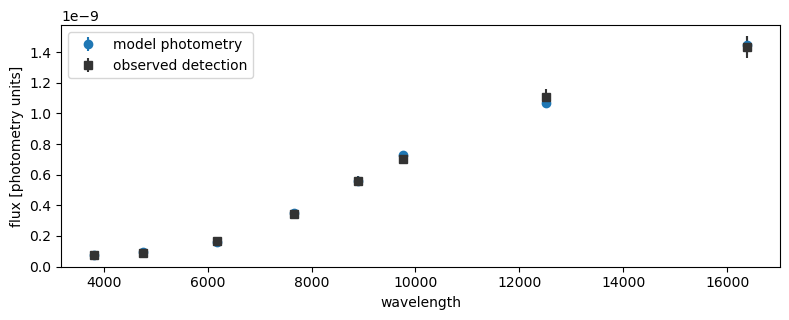

In [4]:
from composed.plot import plot_corner_hexbin, plot_posterior_predictive_sed

plot_corner_hexbin(
    result,
    parameters=["zred", "log10_mass", "logzsol", "dust2", "age_fraction"],
    max_points=30_000,
)
plot_posterior_predictive_sed(
    result, backend, parameters, photometry=data, filters=filters,
    n_draw=150, seed=72,
)


## Posterior SFH and present-day SFR


posterior log10 SFR 16/50/84%: [0.33451266 0.55457824 0.79501223]
LePhare reference log10 SFR: 1.09896


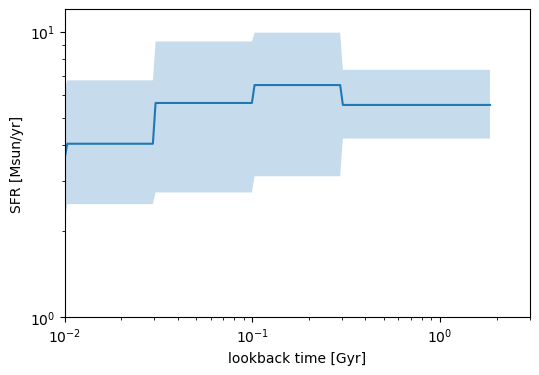

In [5]:
from composed import derive_sfh_quantities

rng = np.random.default_rng(73)
chosen = rng.choice(len(result.samples), size=64, replace=True, p=result.weights)
native_histories = []
current_sfr = []
for theta in result.samples[chosen]:
    derived = derive_sfh_quantities(backend, parameters.to_dict(theta), filters)
    lookback = (derived.time_gyr[-1] - derived.time_gyr)[::-1]
    native_histories.append((lookback, derived.sfr_msun_per_yr[::-1]))
    current_sfr.append(derived.log10_sfr)
max_common_lookback = min(lookback[-1] for lookback, _ in native_histories)
lookback_grid = np.geomspace(0.01, max_common_lookback, 160)
histories = np.asarray([
    np.interp(lookback_grid, lookback, sfr)
    for lookback, sfr in native_histories
])
lo, med, hi = np.quantile(histories, [0.16, 0.5, 0.84], axis=0)
plt.figure(figsize=(6, 4))
plt.fill_between(lookback_grid, lo, hi, alpha=0.25)
plt.plot(lookback_grid, med)
plt.xscale("log"); plt.yscale("log")
plt.xlim(0.01, 3.0); plt.ylim(1.0, 12.0)
plt.xlabel("lookback time [Gyr]"); plt.ylabel("SFR [Msun/yr]")
print("posterior log10 SFR 16/50/84%:", np.quantile(current_sfr, [0.16, 0.5, 0.84]))
print("LePhare reference log10 SFR:", sfr_reference[SINGLE_OBJECT])
